# Day 22 練習：把現成能力黏成一份天氣報告

這份 Notebook 只傳達一件事：**我們不必從零打造氣象資料平台，也能把資料來源、整理程式與繪圖能力接成一條可工作的流程。**

逐格執行時，請一直觀察兩個問題：

1. 這一格加入了哪一塊現成能力？
2. 我們真正自己寫的「膠水」是哪一小段？

最後的流程會是：

```text
公開天氣 API → 整理欄位 → 檢查資料 → 基準圖表 → 交給繪圖 Skill 的任務說明
```

> 資料身分說明：本練習使用 Open-Meteo 的歷史再分析資料。它是真實世界的網格化氣象資料，但不是中央氣象署測站的現地觀測值。

## 第一步：先準備工具與三個地點

這一格只準備 Python 套件、日期與地點座標，還沒有取得任何天氣資料。

**請觀察：**我們只描述「想查哪裡、哪一週」，沒有開始設計資料庫或網站。`USE_LIVE_API=False` 會使用 Notebook 內附的真實資料快照；改成 `True` 才會重新呼叫 API。

In [1]:
from datetime import date
from urllib.parse import urlencode
from urllib.request import urlopen
import json

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

LOCATIONS = {
    "臺北": {"latitude": 25.0375, "longitude": 121.5637},
    "花蓮": {"latitude": 23.9911, "longitude": 121.6112},
    "阿里山": {"latitude": 23.5100, "longitude": 120.8050},
}

START_DATE = "2026-08-10"
END_DATE = "2026-08-16"
USE_LIVE_API = False

print(f"本次範圍：{START_DATE} 到 {END_DATE}")
print("地點：" + "、".join(LOCATIONS))
print(f"是否重新呼叫 API：{USE_LIVE_API}")

本次範圍：2026-08-10 到 2026-08-16
地點：臺北、花蓮、阿里山
是否重新呼叫 API：False


## 第二步：取得資料

Open-Meteo 已經處理了氣象資料的蒐集與供應。我們沒有重建這項能力，只負責提出座標、日期與所需欄位。

為了讓沒有網路的讀者也能完成練習，下面保留了同一支 API 在 2026-08-19 取得的快照。這不是虛構數字；切換到即時模式後，程式會使用相同格式重新下載。

**請觀察：**這一格加入的是「資料來源」，還不是我們最後想看的整齊表格。

In [2]:
SNAPSHOT = [
    {
        "latitude": 25.06151,
        "longitude": 121.5194,
        "elevation": 11.0,
        "daily_units": {
            "time": "iso8601",
            "temperature_2m_max": "°C",
            "temperature_2m_min": "°C",
            "precipitation_sum": "mm",
        },
        "daily": {
            "time": ["2026-08-10", "2026-08-11", "2026-08-12", "2026-08-13", "2026-08-14", "2026-08-15", "2026-08-16"],
            "temperature_2m_max": [32.0, 33.3, 33.3, 34.1, 34.5, 33.4, 33.2],
            "temperature_2m_min": [25.4, 26.9, 26.4, 27.0, 26.4, 26.3, 26.5],
            "precipitation_sum": [11.6, 2.5, 5.2, 3.4, 7.1, 7.0, 5.8],
        },
    },
    {
        "latitude": 24.007029,
        "longitude": 121.59067,
        "elevation": 20.0,
        "daily_units": {
            "time": "iso8601",
            "temperature_2m_max": "°C",
            "temperature_2m_min": "°C",
            "precipitation_sum": "mm",
        },
        "daily": {
            "time": ["2026-08-10", "2026-08-11", "2026-08-12", "2026-08-13", "2026-08-14", "2026-08-15", "2026-08-16"],
            "temperature_2m_max": [32.2, 30.9, 31.9, 32.0, 31.7, 32.8, 31.1],
            "temperature_2m_min": [27.3, 27.6, 26.8, 27.1, 26.6, 26.9, 28.1],
            "precipitation_sum": [2.2, 2.1, 2.2, 2.7, 0.1, 6.9, 0.9],
        },
    },
    {
        "latitude": 23.514936,
        "longitude": 120.88422,
        "elevation": 2220.0,
        "daily_units": {
            "time": "iso8601",
            "temperature_2m_max": "°C",
            "temperature_2m_min": "°C",
            "precipitation_sum": "mm",
        },
        "daily": {
            "time": ["2026-08-10", "2026-08-11", "2026-08-12", "2026-08-13", "2026-08-14", "2026-08-15", "2026-08-16"],
            "temperature_2m_max": [17.2, 22.5, 21.4, 20.8, 19.7, 18.5, 21.4],
            "temperature_2m_min": [13.9, 12.6, 11.4, 12.2, 11.1, 13.9, 13.2],
            "precipitation_sum": [19.0, 5.6, 0.8, 1.9, 5.8, 9.5, 2.4],
        },
    },
]


def fetch_open_meteo(locations, start_date, end_date):
    params = {
        "latitude": ",".join(str(item["latitude"]) for item in locations.values()),
        "longitude": ",".join(str(item["longitude"]) for item in locations.values()),
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
        "timezone": "Asia/Taipei",
    }
    url = "https://archive-api.open-meteo.com/v1/archive?" + urlencode(params)
    with urlopen(url, timeout=30) as response:
        return json.load(response), url


if USE_LIVE_API:
    raw_weather, source_note = fetch_open_meteo(LOCATIONS, START_DATE, END_DATE)
    source_mode = "即時 API"
else:
    raw_weather = SNAPSHOT
    source_note = "Notebook 內附快照（原始來源：Open-Meteo Historical Weather API）"
    source_mode = "離線快照"

print(f"目前使用：{source_mode}")
print(source_note)

目前使用：離線快照
Notebook 內附快照（原始來源：Open-Meteo Historical Weather API）


## 第三步：先看原始輸出，不急著美化

API 回傳的是巢狀資料：單位放在 `daily_units`，每天的數值放在 `daily`。這是資料供應者方便傳輸的格式，不是我們方便分析的格式。

**請觀察：**日期、最高溫、最低溫和降雨量是四個分開的清單。下一格的小程式要做的，只是把它們攤平成一列一天的表格。

In [3]:
print(json.dumps(raw_weather[0], ensure_ascii=False, indent=2))

{
  "latitude": 25.06151,
  "longitude": 121.5194,
  "elevation": 11.0,
  "daily_units": {
    "time": "iso8601",
    "temperature_2m_max": "°C",
    "temperature_2m_min": "°C",
    "precipitation_sum": "mm"
  },
  "daily": {
    "time": [
      "2026-08-10",
      "2026-08-11",
      "2026-08-12",
      "2026-08-13",
      "2026-08-14",
      "2026-08-15",
      "2026-08-16"
    ],
    "temperature_2m_max": [
      32.0,
      33.3,
      33.3,
      34.1,
      34.5,
      33.4,
      33.2
    ],
    "temperature_2m_min": [
      25.4,
      26.9,
      26.4,
      27.0,
      26.4,
      26.3,
      26.5
    ],
    "precipitation_sum": [
      11.6,
      2.5,
      5.2,
      3.4,
      7.1,
      7.0,
      5.8
    ]
  }
}


## 第四步：寫最少的膠水程式

現在才輪到我們自己寫程式。`normalize_weather()` 不預測天氣，也不決定圖表風格；它只負責把 API 格式轉成後續工具都容易理解的表格。

**請觀察：**這裡是整份練習最接近 Glue Coding 的地方——前一個工具的輸出，變成下一個工具的輸入。

In [4]:
def normalize_weather(raw_items, location_names):
    rows = []
    for location_name, item in zip(location_names, raw_items):
        units = item["daily_units"]
        daily = item["daily"]

        if units["temperature_2m_max"] != "°C":
            raise ValueError(f"{location_name} 的溫度單位不是 °C")
        if units["precipitation_sum"] != "mm":
            raise ValueError(f"{location_name} 的降雨單位不是 mm")

        for day, max_temp, min_temp, rain in zip(
            daily["time"],
            daily["temperature_2m_max"],
            daily["temperature_2m_min"],
            daily["precipitation_sum"],
        ):
            rows.append(
                {
                    "date": day,
                    "location": location_name,
                    "max_temp_c": max_temp,
                    "min_temp_c": min_temp,
                    "precipitation_mm": rain,
                }
            )

    result = pd.DataFrame(rows)
    result["date"] = pd.to_datetime(result["date"])
    return result


weather = normalize_weather(raw_weather, LOCATIONS.keys())
weather.head(9)

,date,location,max_temp_c,min_temp_c,precipitation_mm
0,2026-08-10,臺北,32.0,25.4,11.6
1,2026-08-11,臺北,33.3,26.9,2.5
2,2026-08-12,臺北,33.3,26.4,5.2
3,2026-08-13,臺北,34.1,27.0,3.4
4,2026-08-14,臺北,34.5,26.4,7.1
5,2026-08-15,臺北,33.4,26.3,7.0
6,2026-08-16,臺北,33.2,26.5,5.8
7,2026-08-10,花蓮,32.2,27.3,2.2
8,2026-08-11,花蓮,30.9,27.6,2.1


## 第五步：接得上以前，先確認資料沒有偷偷變形

程式成功執行，只能證明沒有立刻報錯。下面檢查每個地點是否都有七天、關鍵欄位是否缺值，以及最高溫是否低於最低溫。

**請觀察：**這些檢查不能證明資料完全正確，但能攔住幾個明顯問題。Glue Coding 不是把接頭插進去就下班。

In [5]:
expected_days = pd.date_range(START_DATE, END_DATE).size
counts = weather.groupby("location")["date"].nunique()

checks = {
    "每個地點都有完整日期": bool((counts == expected_days).all()),
    "關鍵欄位沒有缺值": bool(
        weather[["max_temp_c", "min_temp_c", "precipitation_mm"]]
        .notna()
        .all()
        .all()
    ),
    "最高溫沒有低於最低溫": bool(
        (weather["max_temp_c"] >= weather["min_temp_c"]).all()
    ),
    "降雨量沒有負值": bool((weather["precipitation_mm"] >= 0).all()),
}

for name, passed in checks.items():
    print(("✅" if passed else "❌") + " " + name)

assert all(checks.values()), "資料檢查未通過，請先查看失敗項目。"


✅ 每個地點都有完整日期
✅ 關鍵欄位沒有缺值
✅ 最高溫沒有低於最低溫
✅ 降雨量沒有負值


## 第六步：先畫一張可以核對的基準圖

這張圖不追求投稿等級，只回答兩個問題：三個地點的最高溫如何變化？每天的降雨量是多少？

**請觀察：**普通的 Python 圖表先確認資料與問題對得上。更漂亮的 Skill 不能取代這一步，因為精美地畫錯資料，仍然只是比較昂貴的錯誤。

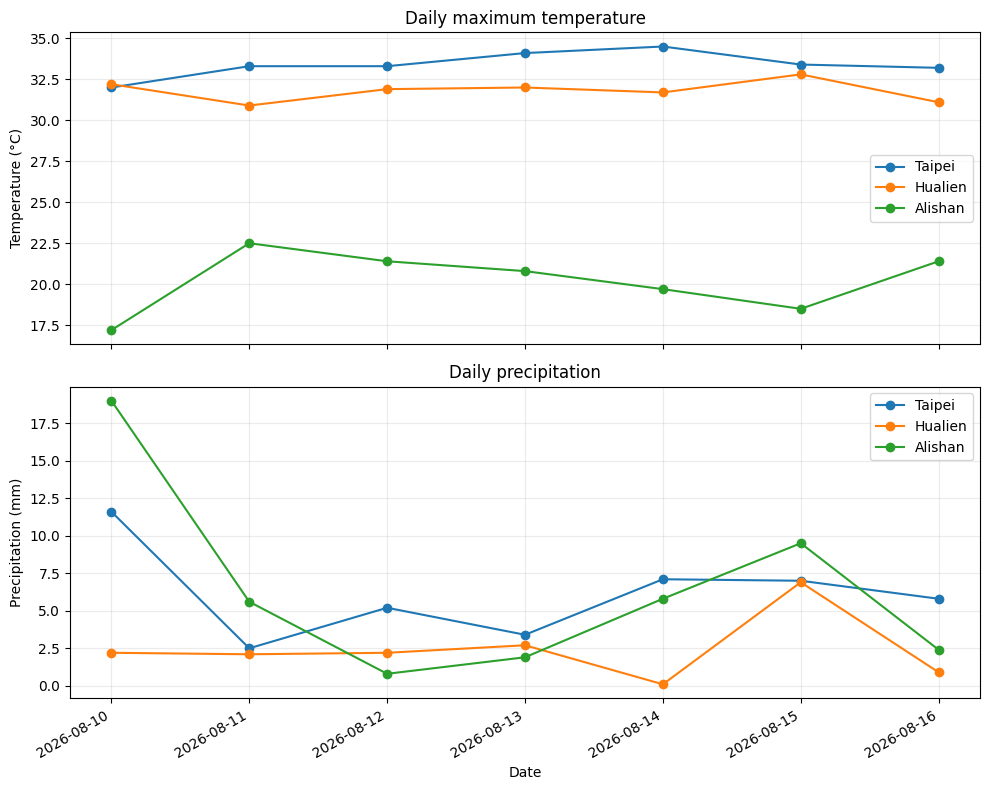

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

english_labels = {"臺北": "Taipei", "花蓮": "Hualien", "阿里山": "Alishan"}

for location, group in weather.groupby("location"):
    label = english_labels[location]
    axes[0].plot(group["date"], group["max_temp_c"], marker="o", label=label)
    axes[1].plot(group["date"], group["precipitation_mm"], marker="o", label=label)

axes[0].set_title("Daily maximum temperature")
axes[0].set_ylabel("Temperature (°C)")
axes[1].set_title("Daily precipitation")
axes[1].set_ylabel("Precipitation (mm)")
axes[1].set_xlabel("Date")

for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 第七步：把資料與問題交給繪圖 Skill

`academic-figure-skill` 是給 Codex、Claude Code 等 Agent 使用的 Skill，不是一般 Python 套件。因此這裡不會寫一個假的 `import academic_figure_skill`。

真正的交接要說清楚四件事：資料是什麼、想回答什麼、哪些事不能亂推論，以及希望收到什麼成果。

**請觀察：**Skill 不必知道資料是怎麼下載的；資料入口也不必知道圖表要怎麼設計。乾淨的表格與任務說明，就是兩塊積木之間的接縫。

In [7]:
clean_csv = weather.to_csv(index=False)

skill_handoff = {
    "data_name": "weather_clean.csv",
    "columns": weather.columns.tolist(),
    "scientific_question": "這一週三個地點的最高溫與每日降雨有何差異？",
    "evidence_boundary": (
        "只能描述表格中的差異；若沒有額外氣象證據，"
        "不可自行宣稱颱風、鋒面或地形是造成差異的原因。"
    ),
    "output": "一張適合教學文章的清楚圖表，保留單位、圖例與資料來源說明。",
}

print("準備交給 Skill 的資料前五行：")
print("\n".join(clean_csv.splitlines()[:6]))
print("\n交接說明：")
print(json.dumps(skill_handoff, ensure_ascii=False, indent=2))

準備交給 Skill 的資料前五行：
date,location,max_temp_c,min_temp_c,precipitation_mm
2026-08-10,臺北,32.0,25.4,11.6
2026-08-11,臺北,33.3,26.9,2.5
2026-08-12,臺北,33.3,26.4,5.2
2026-08-13,臺北,34.1,27.0,3.4
2026-08-14,臺北,34.5,26.4,7.1

交接說明：
{
  "data_name": "weather_clean.csv",
  "columns": [
    "date",
    "location",
    "max_temp_c",
    "min_temp_c",
    "precipitation_mm"
  ],
  "scientific_question": "這一週三個地點的最高溫與每日降雨有何差異？",
  "evidence_boundary": "只能描述表格中的差異；若沒有額外氣象證據，不可自行宣稱颱風、鋒面或地形是造成差異的原因。",
  "output": "一張適合教學文章的清楚圖表，保留單位、圖例與資料來源說明。"
}


## 第八步：真的套用 Academic Figure Skill 的規則

它依照 `academic-figure-skill` 的問題導向、配色、字體、版面、輸出與品質規則，產生可重現的正式圖表。

這個案例在 Skill 的目錄中對應時間序列，所以使用 `LineTrend` 的視覺規則。原始範例的資料結構和天氣資料不同，不能整支程式原封不動搬過來；因此採用「參數繼承」：保留線條、標記、留白與圖例邏輯，資料仍使用前面完整的 21 列，沒有挑掉任何一天。

**請觀察：**同一份 `weather` 表格先產生普通基準圖，再產生 Skill 版圖表。漂亮不是另外捏一份資料，而是改變呈現方法。這一格也會輸出向量 PDF、300 dpi PNG 與實際送進圖表的 CSV。

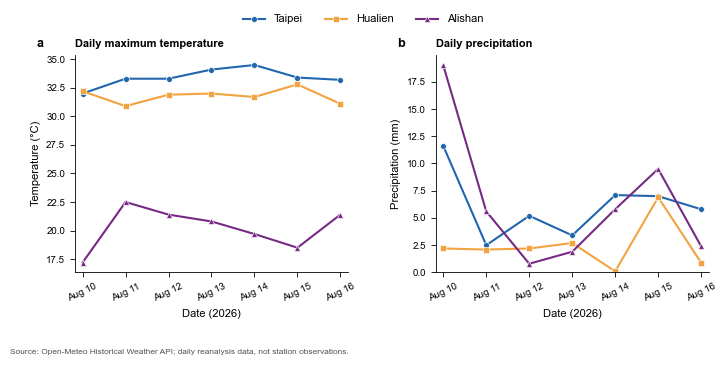

乾淨資料：day22_weather_clean.csv
向量主檔：day22_weather_academic.pdf
PNG 預覽：day22_weather_academic.png


In [8]:
# Academic Figure Skill Asset Confirmation (verified against assets/figures/)
# (a) LineTrend → assets/figures/LineTrend/plot_sweep.py → param inherit
# (b) LineTrend → assets/figures/LineTrend/plot_sweep.py → param inherit
# RULE: "native run" = load pre-rendered PNG via Image.open().ax.imshow().
#       "param inherit" = drawing function below that copies Class A/B/C values.
#       If a panel says "native run" and you write a drawing function, you broke the contract.

from pathlib import Path
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Academic Figure Skill Typography Baseline — COPY VERBATIM, place at TOP of script
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans"],
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 8,
    "figure.titlesize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.6,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "legend.frameon": False,
})

# Academic Figure Skill Nature/Cell/Science Color Palette -- COPY VERBATIM
CATEGORICAL = ["#2166AC", "#B2182B", "#1B7837", "#F1A340", "#762A83", "#666666"]
CATEGORICAL_EXTENDED = [
    "#2166AC", "#B2182B", "#1B7837", "#F1A340", "#762A83", "#666666",
    "#4393C3", "#D6604D", "#5AAE61", "#B35806", "#9970AB", "#999999",
]
DIVERGING   = ["#2166AC", "#F7F7F7", "#B2182B"]
SEQUENTIAL  = ["#F7FBFF", "#6BAED6", "#08306B"]
ACCENT_RED  = "#B2182B"
GREY        = "#999999"
BLACK       = "#222222"

# Academic Figure Skill Export Baseline — COPY VERBATIM
mpl.rcParams.update({
    "pdf.fonttype": 42,
    "svg.fonttype": "none",
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

def save_cns_figure(fig, filename):
    """Standard Academic Figure Skill export: vector PDF + 300dpi PNG preview."""
    fig.savefig(f"{filename}.pdf", bbox_inches="tight", dpi=300)
    fig.savefig(f"{filename}.png", bbox_inches="tight", dpi=300)


output_directory = Path("Day22") if Path("Day22").exists() else Path(".")
output_directory.mkdir(parents=True, exist_ok=True)
clean_data_path = output_directory / "day22_weather_clean.csv"
figure_stem = output_directory / "day22_weather_academic"
weather.to_csv(clean_data_path, index=False)

location_style = {
    "臺北": {"label": "Taipei", "color": CATEGORICAL[0], "marker": "o"},
    "花蓮": {"label": "Hualien", "color": CATEGORICAL[3], "marker": "s"},
    "阿里山": {"label": "Alishan", "color": CATEGORICAL[4], "marker": "^"},
}

mm_to_inch = 1 / 25.4
fig, axes = plt.subplots(
    1,
    2,
    figsize=(183 * mm_to_inch, 92 * mm_to_inch),
    sharex=True,
)

for location, group in weather.groupby("location", sort=False):
    style = location_style[location]
    axes[0].plot(
        group["date"], group["max_temp_c"],
        color=style["color"], marker=style["marker"],
        linewidth=1.5, markersize=4.2,
        markeredgecolor="white", markeredgewidth=0.45,
        label=style["label"],
    )
    axes[1].plot(
        group["date"], group["precipitation_mm"],
        color=style["color"], marker=style["marker"],
        linewidth=1.5, markersize=4.2,
        markeredgecolor="white", markeredgewidth=0.45,
        label=style["label"],
    )

axes[0].set_title("Daily maximum temperature", loc="left", fontweight="bold")
axes[0].set_ylabel("Temperature (°C)")
axes[1].set_title("Daily precipitation", loc="left", fontweight="bold")
axes[1].set_ylabel("Precipitation (mm)")
axes[1].set_ylim(bottom=0)

for label, ax in zip(["a", "b"], axes):
    ax.text(-0.14, 1.08, label, transform=ax.transAxes,
            fontsize=9, fontweight="bold", va="top")
    ax.margins(x=0.03)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.tick_params(axis="x", rotation=25)
    ax.set_xlabel("Date (2026)")

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels, loc="upper center",
    bbox_to_anchor=(0.5, 0.98), ncol=3, frameon=False,
)
fig.text(
    0.01, 0.015,
    "Source: Open-Meteo Historical Weather API; daily reanalysis data, not station observations.",
    fontsize=6, color="#555555",
)
fig.subplots_adjust(left=0.10, right=0.98, bottom=0.24, top=0.84, wspace=0.32)

save_cns_figure(fig, str(figure_stem))
plt.show()

print(f"乾淨資料：{clean_data_path}")
print(f"向量主檔：{figure_stem}.pdf")
print(f"PNG 預覽：{figure_stem}.png")

## 第九步：檢查漂亮圖表有沒有偷偷換資料

圖變漂亮之後，最危險的反而是放下戒心。這一格不靠「看起來差不多」判斷，而是檢查輸出檔、資料筆數、每個地點的日期數，以及兩個面板實際使用的欄位。

Skill 要求統計與再現性報告；這個案例沒有重複實驗，也沒有做推論統計，所以不能硬塞平均值誤差棒或 p 值。每一個點代表指定座標在某一天的再分析值，圖表只做描述性比較。

**請觀察：**正式圖表仍然使用 `weather` 的 21 列。美化改變的是字體、配色、版面與輸出品質，不是證據。

In [9]:
from PIL import Image

png_path = Path(f"{figure_stem}.png")
pdf_path = Path(f"{figure_stem}.pdf")

with Image.open(png_path) as image:
    png_size = image.size
    png_dpi = image.info.get("dpi")

temperature_variation = (
    weather["max_temp_c"].max() - weather["max_temp_c"].min()
) / weather["max_temp_c"].mean()
rain_mean = weather["precipitation_mm"].mean()
rain_variation = (
    weather["precipitation_mm"].max() - weather["precipitation_mm"].min()
) / rain_mean

reloaded_weather = pd.read_csv(clean_data_path, parse_dates=["date"])
same_values = weather.reset_index(drop=True).equals(
    reloaded_weather[weather.columns].reset_index(drop=True)
)

figure_checks = {
    "正式圖使用完整 21 列資料": len(weather) == 21,
    "每個地點都有 7 天": bool((weather.groupby("location")["date"].nunique() == 7).all()),
    "輸入 CSV 與記憶體表格逐值一致": same_values,
    "PDF 向量主檔存在且非空": pdf_path.exists() and pdf_path.stat().st_size > 0,
    "PNG 預覽存在且非空": png_path.exists() and png_path.stat().st_size > 0,
    "兩個面板都有足夠變化": temperature_variation > 0.1 and rain_variation > 0.1,
}

for name, passed in figure_checks.items():
    print(("✅" if passed else "❌") + " " + name)

assert all(figure_checks.values()), "正式圖表檢查未通過。"

print()
print(f"PNG 尺寸：{png_size[0]} × {png_size[1]} pixels")
print(f"PNG DPI metadata：{png_dpi}")
print(f"最高溫面板變化比：{temperature_variation:.2f}")
print(f"降雨面板變化比：{rain_variation:.2f}")
print()
print("統計與再現性說明：")
print("- n = 每個地點 7 個每日再分析值，共 21 列。")
print("- 沒有計算組平均的誤差範圍，也沒有進行假設檢定。")
print("- 面板 a 來自 max_temp_c；面板 b 來自 precipitation_mm。")
print("- 每個資料點可由 location + date 回到 day22_weather_clean.csv。")

✅ 正式圖使用完整 21 列資料
✅ 每個地點都有 7 天
✅ 輸入 CSV 與記憶體表格逐值一致
✅ PDF 向量主檔存在且非空
✅ PNG 預覽存在且非空
✅ 兩個面板都有足夠變化

PNG 尺寸：2181 × 1096 pixels
PNG DPI metadata：(299.9994, 299.9994)
最高溫面板變化比：0.61
降雨面板變化比：3.79

統計與再現性說明：
- n = 每個地點 7 個每日再分析值，共 21 列。
- 沒有計算組平均的誤差範圍，也沒有進行假設檢定。
- 面板 a 來自 max_temp_c；面板 b 來自 precipitation_mm。
- 每個資料點可由 location + date 回到 day22_weather_clean.csv。


## 第十步：先從數字產生可驗證的觀察

最後一格不請語言模型自由發揮，而是先從表格計算幾個可以核對的結果。之後若要請 AI 改寫成文章，也應把這些數字與原始表格一起提供。

**請觀察：**「哪裡最熱、哪一天雨最多」是資料支持的觀察；「為什麼會這樣」仍然是另一個需要證據的問題。

In [10]:
weekly = (
    weather.groupby("location")
    .agg(
        highest_max_temp_c=("max_temp_c", "max"),
        total_precipitation_mm=("precipitation_mm", "sum"),
    )
    .sort_values("highest_max_temp_c", ascending=False)
)

wettest_row = weather.loc[weather["precipitation_mm"].idxmax()]

display(weekly)
print(
    f"這份資料中，單日降雨量最高的是{wettest_row['location']}，"
    f"日期為 {wettest_row['date'].date()}，"
    f"降雨量為 {wettest_row['precipitation_mm']:.1f} mm。"
)
print("以上只能描述資料中的數值，不能單靠這張表判斷成因。")

,highest_max_temp_c,total_precipitation_mm
location,,
臺北,34.5,42.6
花蓮,32.8,17.1
阿里山,22.5,45.0


這份資料中，單日降雨量最高的是阿里山，日期為 2026-08-10，降雨量為 19.0 mm。
以上只能描述資料中的數值，不能單靠這張表判斷成因。


## 回頭看：我們真正自己做了什麼？

- Open-Meteo 負責提供歷史天氣資料。
- `normalize_weather()` 負責把 API 格式整理成共通表格。
- 檢查程式負責攔住明顯的日期、缺值與單位問題。
- Matplotlib 負責產生可核對的基準圖。
- Academic Figure Skill 的規則負責圖型選擇、正式配色、排版、輸出與品質檢查。
- 人負責確認資料身分、限制，以及文字有沒有超出證據。

執行完畢後，請沿著下面這條路倒著檢查一次：

```text
原始資料從哪裡來
→ 整理程式改了哪些欄位
→ 圖表實際使用哪一份資料
→ 文字結論依據哪一個數字
→ 人應該在哪裡停下來檢查
```

資料成功流到最後一格，不代表結論自動成立。保留原始輸出、中間表格和檢查結果，才能從 AI 寫出的句子一路走回證據，避免被看似合理的流暢回答誤導。

執行完畢後，請沿著下面這條路倒著檢查一次：

```text
原始資料從哪裡來
→ 整理程式改了哪些欄位
→ 正式圖表實際使用哪一份資料
→ 文字結論依據哪一個數字
→ 人應該在哪裡停下來檢查
```

資料成功流到最後一格，不代表結論自動成立。保留原始輸出、中間表格、正式圖表的輸入檔和檢查結果，才能從 AI 寫出的句子一路走回證據，避免被看似合理的流暢回答誤導。


這就是這份練習想展示的 Glue Coding：**不是每一塊都自己做，而是看懂每一塊負責什麼，再補上必要的接縫。**

如果未來把 Open-Meteo 換成中央氣象署 API 或 Twinkle Hub，應優先改寫「資料入口」，而不是推倒後面的檢查、表格與繪圖流程。